> https://docs.langchain.com/oss/python/langgraph/workflows-agents#evaluator-optimizer

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser

llm = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
)

In [5]:
from typing import TypedDict

# 그래프 상태
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

In [6]:
from pydantic import BaseModel, Field
from typing_extensions import Literal

# 평가에 사용할 구조화된 출력(Structured output)을 위한 스키마
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="농담이 재미있는지 없는지 결정합니다.",
    )
    feedback: str = Field(
        description="농담이 재미없다면, 어떻게 개선할 수 있을지 피드백을 제공합니다.",
    )


# 구조화된 출력을 사용하도록 LLM 설정
evaluator = llm.with_structured_output(Feedback)

In [14]:
# 노드 (Nodes)
def llm_call_generator(state: State):
    """LLM이 농담을 생성합니다."""

    if state.get("feedback"):
        msg = llm.invoke(
            f"{state['topic']}에 대한 농담을 작성하되, 다음 피드백을 반영하세요: {state['feedback']}"
        )
    else:
        msg = llm.invoke(f"{state['topic']}에 대한 농담을 작성하세요.")
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM이 농담을 평가합니다."""

    grade = evaluator.invoke(f"다음 농담을 평가하세요: {state['joke']}")

    print("평가:", grade)
    print("-" * 30)
    
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# 평가자의 피드백을 바탕으로 농담 생성기로 돌아갈지, 혹은 종료할지 결정하는 조건부 엣지 함수
def route_joke(state: State):
    """평가자의 피드백을 바탕으로 농담 생성기로 돌아가거나 종료하도록 라우팅합니다."""

    if state["funny_or_not"] == "funny":
        return "합격"
    elif state["funny_or_not"] == "not funny":
        return "불합격 + 피드백"

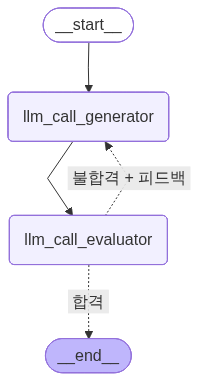

In [15]:
from langgraph.graph import StateGraph, START, END

# 워크플로우 구성
optimizer_builder = StateGraph(State)

# 노드 추가
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# 노드를 연결하는 엣지 추가
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # route_joke에서 반환된 이름 : 이동할 다음 노드의 이름
        "합격": END,
        "불합격 + 피드백": "llm_call_generator",
    },
)

# 워크플로우 컴파일
optimizer_workflow = optimizer_builder.compile()
optimizer_workflow

In [16]:
# 실행
state = optimizer_workflow.invoke({"topic": "고양이"})
print(state["joke"])

평가: grade='funny' feedback='고양이를 소재로 한 농담들이 가볍고 유쾌하며, 고양이의 실제 행동 패턴을 잘 반영하여 재미있습니다.'
------------------------------
[{'type': 'text', 'text': '고양이에 관한 소소하고 귀여운 농담 몇 가지를 준비했습니다!\n\n**1. 고양이와 컴퓨터**\nQ: 고양이가 컴퓨터를 정말 좋아하는 이유는 뭘까요?\nA: \'마우스\'를 잡을 수 있어서요! (하지만 잡으면 바로 고장 내는 게 함정이죠.)\n\n**2. 고양이의 직업**\nQ: 고양이가 가장 잘하는 운동은 무엇일까요?\nA: \'캣\'치볼!\n\n**3. 고양이의 고백**\n고양이가 집사에게 사랑한다고 말하는 방법은?\n"야옹(나 좀 봐주라)~" (물론 1분 뒤에 무시합니다.)\n\n**4. 고양이의 철학**\nQ: 고양이는 왜 항상 늦게 일어날까요?\nA: 어제 밤새도록 집사가 잘 자는지 \'감시\'하느라 피곤했거든요.\n\n**5. 고양이의 수학**\nQ: 고양이가 가장 좋아하는 수학 도형은?\nA: \'캣\'형 도형 (사실 그냥 박스 안에 들어가면 그게 제일 좋은 도형입니다.)\n\n마음에 드셨나요? 고양이는 역시 존재 자체가 농담처럼 귀여운 것 같아요! 🐾', 'extras': {'signature': 'EjQKMgEMOdbH4HPo2X1GOCQOlsTQI8epieJDnyhWQHUXHXjcdAEEY55Soi2xBgdypmo/IIGS'}}]
